# Auditoría semántica de la taxonomía PAE (embeddings)


Este notebook realiza una auditoría semántica de una taxonomía técnica con el objetivo de identificar:
- (i) categorías potencialmente duplicadas o muy solapadas,
- (ii) categorías inconsistentes dentro de su subárea (outliers) y
- (iii) niveles de coherencia semántica intra-subárea frente a inter-subárea.

La auditoría se basa en embeddings de lenguaje aplicados al texto de cada categoría, considerando que el campo text contiene la descripción de la categoría.

In [ ]:
from google.colab import files
# sube el fichero aerotax_transformado.csv
uploaded = files.upload()

Saving aerotax_transformado.csv to aerotax_transformado.csv


In [ ]:
!pip -q install pandas sentence-transformers scikit-learn


In [ ]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

Cargamos el fichero csv de la taxonomía:

In [ ]:
INPUT_CSV = "aerotax_transformado.csv"

df = pd.read_csv(INPUT_CSV)

expected = {"category_code", "category_label", "parent_code", "text"}
if not expected.issubset(df.columns):
    raise ValueError(f"Se esperaban columnas {expected}. Encontradas: {set(df.columns)}")

df.head()

,category_code,category_label,parent_code,text
0,1A2,Unsteady Aerodynamics,1A0,"Unsteady Aerodynamics - In aerodynamics, unste..."
1,1A11,External Noise Prediction,1A0,External Noise Prediction - Prediction of airc...
2,1A6,Wing Design,1A0,Wing Design - The main objective of the wing d...
3,1A7,Aerodynamic of External and Removable Items,1A0,Aerodynamic of External and Removable Items - ...
4,1A9,Wind Tunnel Measuring Techniques,1A0,Wind Tunnel Measuring Techniques - Conventiona...


Concatenaos el título de la label y su descripción, para obtener un texto completo con más información sobre la label.

In [ ]:
df["full_text"] = (
    df["category_label"].fillna("") + ". " +
    df["text"].fillna("")
).str.strip()

Cargamos un modelo de sentence embbedding para representar cada uno de estos textos. Cada txto es representado con un vector de dimensión 768

# 🧠 Modelo: all-mpnet-base-v2

El modelo **all-mpnet-base-v2** es un modelo de *Sentence Transformers* diseñado para generar **embeddings semánticos** a partir de texto. Convierte frases en vectores numéricos que capturan su significado, permitiendo comparar similitud entre textos, realizar búsquedas semánticas o agrupar información.


El modelo **all-mpnet-base-v2** es una solución potente y equilibrada para tareas de procesamiento semántico, destacando por su alta precisión en comparación de texto y su capacidad para capturar significado contextual.


## 🧬 Arquitectura

- Basado en **MPNet (Masked and Permuted Pre-training)**
- Combina ideas de:
  - BERT (enmascaramiento de tokens)
  - XLNet (predicción en orden permutado). No sigue siempre el orden normal de la frase. Entrena el modelo con órdenes aleatorios (permutaciones). Por ejemplo, "Me gusta aprender inteligencia artificial", puede entrenar con "gusta → Me → artificial → aprender → inteligencia"

### 🔹 Estructura interna
- 12 capas Transformer
- 768 dimensiones ocultas
- 12 cabezas de atención
- ~110 millones de parámetros


## ⚙️ Funcionamiento

### 1. Tokenización
El texto se divide en tokens usando un tokenizador tipo WordPiece/BPE.

### 2. Procesamiento
Los tokens pasan por el modelo Transformer:
- Self-attention
- Redes feed-forward

### 3. Pooling
Se aplica **mean pooling** (promedio de todos los tokens) para obtener un único vector por frase.

### 4. Normalización
Opcionalmente se normaliza el vector (norma L2) para facilitar comparaciones.


## 📐 Características del embedding

- Dimensión: 768
- Tipo: vector denso
- Espacio: semántico continuo

👉 Frases similares → vectores cercanos  
👉 Frases distintas → vectores lejanos  


## 🎯 Entrenamiento

### 🔹 Técnica principal
- **Contrastive Learning**

El modelo aprende a:
- Acercar embeddings de frases similares
- Alejar embeddings de frases diferentes

### 🔹 Datos de entrenamiento
- Más de 1.000 millones de pares de frases
- Incluye:
  - Pregunta-respuesta (QA)
  - Inferencia textual (NLI)
  - Paraphrase datasets

### 🔹 Función de pérdida
- Multiple Negatives Ranking Loss

## ⚡ Rendimiento

- Longitud máxima: ~384 tokens
- Velocidad: media
- Precisión: alta en tareas semánticas
- Recomendado uso con GPU (aunque funciona en CPU)



## 📊 Aplicaciones

- Búsqueda semántica
- Comparación de similitud entre textos
- Clustering de documentos
- Sistemas RAG (búsqueda + generación)

---

## 🔗 Comparación con otros modelos

| Modelo        | Dimensión | Precisión | Velocidad |
|---------------|----------|----------|----------|
| MiniLM        | 384      | Media    | Muy alta |
| MPNet  | 768      | Alta     | Media    |
| RoBERTa-large | 1024     | Muy alta | Baja     |

---

## ⚠️ Limitaciones

- Puede truncar textos largos
- Mayor consumo que modelos ligeros
- No realiza razonamiento complejo

---



In [ ]:
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

model = SentenceTransformer(MODEL_NAME)

emb = model.encode(
    df["full_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

emb.shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

(151, 768)

Obtenemos la similitud de todos los textos entre ellos con la función de la distancia del coseno:

In [ ]:
S = cosine_similarity(emb)
# rellenamos la diagonal con -1
np.fill_diagonal(S, -1.0)


## Detectar categorías potencialmente duplicadas o muy solapadas

In [ ]:
def top_pairs(sim_matrix, top_n=50):
    n = sim_matrix.shape[0]
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            pairs.append((i, j, sim_matrix[i, j]))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_n]

pairs = top_pairs(S, top_n=60)

rows = []
for i, j, score in pairs:
    rows.append({
        "similarity": float(score),
        "code_1": df.loc[i, "category_code"],
        "label_1": df.loc[i, "category_label"],
        "code_2": df.loc[j, "category_code"],
        "label_2": df.loc[j, "category_label"],
    })

df_pairs = pd.DataFrame(rows)
display(df_pairs.head(20))


OUTPUT_FILE = "semantic_most_similar_category_pairs.csv"

df_pairs.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

print(f"Fichero generado correctamente: {OUTPUT_FILE}")
print(f"Número de pares guardados: {len(df_pairs)}")

files.download(OUTPUT_FILE)

,similarity,code_1,label_1,code_2,label_2
0,0.878110,1B14,Aircraft Security,1D16,Aircraft Security
1,0.855336,1K0,Unmanned Aerial Systems Technologies,1K1,UAV technologies
2,0.836490,1E3,Aircraft Performance Analysis,1F24,Aircraft Performance Assessment
3,0.833690,1G10,Airline Operations,1G9,Airport Operations
4,0.827380,1A11,External Noise Prediction,1B10,Internal Noise prediction
5,0.814374,1D1,Avionics,1D0,"Aircraft Avionics, Systems & Equipments"
6,0.807851,1F32,Large scale validation Experiments,1F33,Large scale validation Platforms
7,0.807465,1F25,Airport Performance Assessment,1F24,Aircraft Performance Assessment
8,0.804112,1D16,Aircraft Security,1H4,Airport Security
9,0.801834,1K4,UAV-ATM technologies,1K0,Unmanned Aerial Systems Technologies


Fichero generado correctamente: semantic_most_similar_category_pairs.csv
Número de pares guardados: 60


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Categorías más “genéricas” o más “aisladas”

### Categorías más genéricas

In [ ]:
mean_sim = S.mean(axis=1)

df["mean_similarity_to_others"] = mean_sim

# ¿Cuán parecida es esta categoría, en promedio, al resto de categorías?
# Más genéricas (muy similares a muchas otras)
df.sort_values("mean_similarity_to_others", ascending=False).head(10)

,category_code,category_label,parent_code,text,full_text,mean_similarity_to_others
61,1D0,"Aircraft Avionics, Systems & Equipments",NaN,"Aircraft Avionics, Systems & Equipments - DEFI...","Aircraft Avionics, Systems & Equipments. Aircr...",0.407902
59,1D1,Avionics,1D0,Avionics - DEFINITION: Contains all sub-domain...,Avionics. Avionics - DEFINITION: Contains all ...,0.402907
101,1F0,Integrated Design & Validation (methods & tools),NaN,Integrated Design & Validation (methods & tool...,Integrated Design & Validation (methods & tool...,0.397397
73,1E0,Flight Mechanics,NaN,Flight Mechanics - DEFINITION: It comprises al...,Flight Mechanics. Flight Mechanics - DEFINITIO...,0.362891
121,1G1,Overall ATM,1G0,Overall ATM - DEFINITION: Contains all sub-dom...,Overall ATM. Overall ATM - DEFINITION: Contain...,0.357325
74,1E5,System Failure and Damage Analysis,1E0,System Failure and Damage Analysis - DEFINITIO...,System Failure and Damage Analysis. System Fai...,0.356932
49,1D21,Environmental control System,1D0,Environmental control System - DEFINITION: Air...,Environmental control System. Environmental co...,0.350336
118,1G4,Communications and Systems Technology,1G0,Communications and Systems Technology - DEFINI...,Communications and Systems Technology. Communi...,0.349941
70,1E2,Flight control system,1E0,Flight control system - DEFINITION: The flight...,Flight control system. Flight control system -...,0.349487
63,1D10,Avionics Integration,1D0,Avionics Integration - DEFINITION: With the in...,Avionics Integration. Avionics Integration - D...,0.345806


In [ ]:
df["mean_similarity_to_others"].describe()


,mean_similarity_to_others
count,151.000000
mean,0.279587
std,0.047234
min,0.155608
25%,0.248054
50%,0.281620
75%,0.311166
max,0.407902


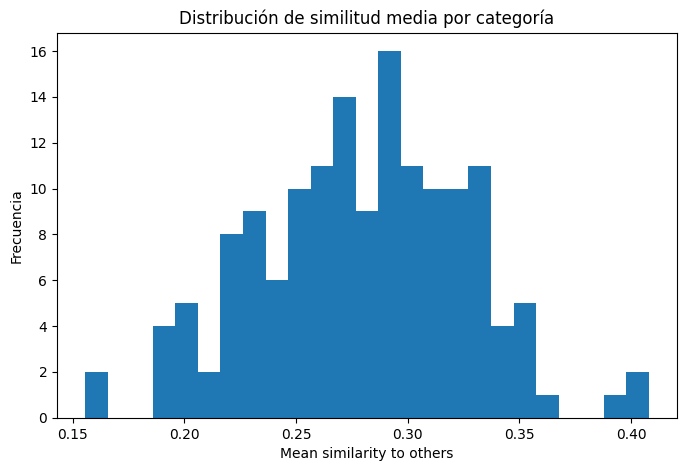

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["mean_similarity_to_others"], bins=25)
plt.title("Distribución de similitud media por categoría")
plt.xlabel("Mean similarity to others")
plt.ylabel("Frecuencia")
plt.show()


Lo que se observa:

* Rango aproximado: 0.16 – 0.41
* La mayor concentración está entre 0.24 y 0.33
* Tiene forma aproximadamente unimodal
* No parece tener una cola extrema pronunciada



Esto sugiere:

✅ La taxonomía es relativamente homogénea
✅ No hay categorías absurdamente genéricas (tipo 0.60+)
✅ No hay categorías completamente desconectadas del dominio

📌 2️⃣ Qué significa el rango
🔹 Valores bajos (~0.16–0.20)

Las categorías con valores bajos (0.16-0.20):

* Son muy específicas
* Comparten poco vocabulario con el resto

Pueden ser muy técnicas o muy especializadas o mal descritas. Revisarlas manualmente es interesante.

Las categorías con valores medios (0.2-0.40) don “centro natural” de la taxonomía. Indica:
* Buena separación conceptual
* Dominio coherente
* Espacio semántico estructurado

Esto es buena señal.


En los valores altos (~0.35–0.40), están las categorías más generales:
- Roots
- Términos paraguas
- Conceptos amplios del dominio

Pero ojo, 0.40 no es extremadamente alto. No hay evidencia de categorías excesivamente genéricas

¿Qué nos dice sobre la calidad de la taxonomía?

Desde un punto de vista estructural-semántico:

* No hay bimodalidad → no parece haber dos taxonomías mezcladas
* No hay outliers extremos → no hay categorías “fuera de dominio”
* No hay valores anormalmente altos → no hay duplicados claros

Esto es bastante buena noticia.

Implicación para el modelo de clasificación

Dado que la distribución es compacta:
* No parece haber categorías que dominen semánticamente.
* El clasificador no debería tener sesgo estructural fuerte.
* Es un buen candidato para clasificación plana.


🎯 Conclusión

La taxonomía parece:

* Semánticamente coherente
* Razonablemente equilibrada
* No redundante
* Bien separada conceptualmente

Desde el punto de vista de embeddings, es un buen punto de partida.

In [ ]:
print(df["mean_similarity_to_others"].mean())
print(df["mean_similarity_to_others"].std())

0.27958715
0.04723433032631874


## ¿Hay outliers reales?

Si no hay valores con |z| > 2, la taxonomía es muy estable.

In [ ]:
z_scores = (df["mean_similarity_to_others"] - 0.27958715) / 0.04723433
df["z_score"] = z_scores

df.sort_values("z_score", ascending=False).head(10)


,category_code,category_label,parent_code,text,full_text,mean_similarity_to_others,z_score
61,1D0,"Aircraft Avionics, Systems & Equipments",NaN,"Aircraft Avionics, Systems & Equipments - DEFI...","Aircraft Avionics, Systems & Equipments. Aircr...",0.407902,2.716558
59,1D1,Avionics,1D0,Avionics - DEFINITION: Contains all sub-domain...,Avionics. Avionics - DEFINITION: Contains all ...,0.402907,2.610801
101,1F0,Integrated Design & Validation (methods & tools),NaN,Integrated Design & Validation (methods & tool...,Integrated Design & Validation (methods & tool...,0.397397,2.494154
73,1E0,Flight Mechanics,NaN,Flight Mechanics - DEFINITION: It comprises al...,Flight Mechanics. Flight Mechanics - DEFINITIO...,0.362891,1.763632
121,1G1,Overall ATM,1G0,Overall ATM - DEFINITION: Contains all sub-dom...,Overall ATM. Overall ATM - DEFINITION: Contain...,0.357325,1.645784
74,1E5,System Failure and Damage Analysis,1E0,System Failure and Damage Analysis - DEFINITIO...,System Failure and Damage Analysis. System Fai...,0.356932,1.637461
49,1D21,Environmental control System,1D0,Environmental control System - DEFINITION: Air...,Environmental control System. Environmental co...,0.350336,1.497818
118,1G4,Communications and Systems Technology,1G0,Communications and Systems Technology - DEFINI...,Communications and Systems Technology. Communi...,0.349941,1.489458
70,1E2,Flight control system,1E0,Flight control system - DEFINITION: The flight...,Flight control system. Flight control system -...,0.349487,1.479862
63,1D10,Avionics Integration,1D0,Avionics Integration - DEFINITION: With the in...,Avionics Integration. Avionics Integration - D...,0.345806,1.401932


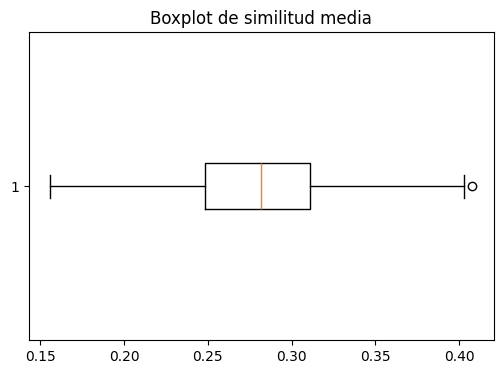

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df["mean_similarity_to_others"], vert=False)
plt.title("Boxplot de similitud media")
plt.show()


En el gráfico vemos:

- Mediana ≈ 0.28–0.29, está muy cerca de la media (~0.2796), lo que indica distribución aproximadamente simétrica. No hay sesgo fuerte hacia categorías demasiado generales
- IQR (rango intercuartílico) aprox. entre 0.25 y 0.31. Es decir, El 50% central de las categorías está aproximadamente entre 0.25 — 0.31, que es un rango estrecho → baja dispersión → estructura semántica estable.
- Bigote inferior ≈ 0.16, indica que hay algunas categorías bastante específicas, pero no parecen ser outliers extremos (no hay puntos muy aislados abajo).

- Bigote superior ≈ 0.40, indica categorías bastante generales. El punto alrededor de 0.40 podría ser un outlier leve, pero está dentro de ~2σ. No es extremo.

Este boxplot es típico de una taxonomía bien construida:

✔ Cohesión global del dominio
✔ Especialización razonable
✔ Sin categorías absurdamente genéricas
✔ Sin categorías desconectadas

No hay señales de:

- Redundancia fuerte
- Mezcla de dominios
- Subtaxonomías independientes

🔬 4️⃣ Implicación metodológica

Desde el punto de vista de clasificación automática:
- No hay categorías que “dominen” el espacio semántico.
- No hay categorías que estén demasiado aisladas.
- El espacio es relativamente homogéneo.

Eso facilita:
- Entrenamiento supervisado estable.
- Retrieval con embeddings sin sesgo fuerte.
- Uso de LLMs con menor tendencia a colapsar en categorías genéricas.

🎯 5️⃣ Conclusión

La distribución es compacta, equilibrada y saludable.

Para un proyecto de clasificación científica, esto es una muy buena señal.

### Top 5% más generales

In [ ]:
threshold_high = np.percentile(df["mean_similarity_to_others"], 95)

df[df["mean_similarity_to_others"] >= threshold_high] \
    .sort_values("mean_similarity_to_others", ascending=False)

,category_code,category_label,parent_code,text,full_text,mean_similarity_to_others
61,1D0,"Aircraft Avionics, Systems & Equipments",NaN,"Aircraft Avionics, Systems & Equipments - DEFI...","Aircraft Avionics, Systems & Equipments. Aircr...",0.407902
59,1D1,Avionics,1D0,Avionics - DEFINITION: Contains all sub-domain...,Avionics. Avionics - DEFINITION: Contains all ...,0.402907
101,1F0,Integrated Design & Validation (methods & tools),NaN,Integrated Design & Validation (methods & tool...,Integrated Design & Validation (methods & tool...,0.397397
73,1E0,Flight Mechanics,NaN,Flight Mechanics - DEFINITION: It comprises al...,Flight Mechanics. Flight Mechanics - DEFINITIO...,0.362891
121,1G1,Overall ATM,1G0,Overall ATM - DEFINITION: Contains all sub-dom...,Overall ATM. Overall ATM - DEFINITION: Contain...,0.357325
74,1E5,System Failure and Damage Analysis,1E0,System Failure and Damage Analysis - DEFINITIO...,System Failure and Damage Analysis. System Fai...,0.356932
49,1D21,Environmental control System,1D0,Environmental control System - DEFINITION: Air...,Environmental control System. Environmental co...,0.350336
118,1G4,Communications and Systems Technology,1G0,Communications and Systems Technology - DEFINI...,Communications and Systems Technology. Communi...,0.349941


### Categorías más aisladas

In [ ]:
df.sort_values("mean_similarity_to_others", ascending=True).head(10)


,category_code,category_label,parent_code,text,full_text,mean_similarity_to_others
16,1B2,Non-Metallic Materials & basic processes,1B0,Non-Metallic Materials & basic processes - Org...,Non-Metallic Materials & basic processes. Non-...,0.155608
135,1J4,Hybrid & Electric Power and Propulsion,1J0,Hybrid & Electric Power and Propulsion - DEFIN...,Hybrid & Electric Power and Propulsion. Hybrid...,0.165222
39,1C12,Experimental Facilities and Measurement Techni...,1C0,Experimental Facilities and Measurement Techni...,Experimental Facilities and Measurement Techni...,0.186747
89,1F27,Numerical Models (including Fast Time Simulation),1F0,Numerical Models (including Fast Time Simulati...,Numerical Models (including Fast Time Simulati...,0.186982
13,1B8,Smart Materials and Structures,1B0,Smart Materials and Structures - This domain c...,Smart Materials and Structures. Smart Material...,0.190109
54,1D11,Optics - Optronics - Lasers - Image processing...,1D0,Optics - Optronics - Lasers - Image processing...,Optics - Optronics - Lasers - Image processing...,0.192891
128,1I2,Human Information Processing,1I0,Human Information Processing - DEFINITION: Res...,Human Information Processing. Human Informatio...,0.197055
111,1G12,R&D Management and Co-ordination,1G0,R&D Management and Co-ordination - DEFINITION:...,R&D Management and Co-ordination. R&D Manageme...,0.199800
4,1A9,Wind Tunnel Measuring Techniques,1A0,Wind Tunnel Measuring Techniques - Conventiona...,Wind Tunnel Measuring Techniques. Wind Tunnel ...,0.200492
15,1B1,Metalic Materials & basic processes,1B0,Metalic Materials & basic processes - High tem...,Metalic Materials & basic processes. Metalic M...,0.202989


### Bottom 5% más específicos

In [ ]:
threshold_low = np.percentile(df["mean_similarity_to_others"], 5)

df[df["mean_similarity_to_others"] <= threshold_low] \
    .sort_values("mean_similarity_to_others", ascending=True)


,category_code,category_label,parent_code,text,full_text,mean_similarity_to_others
16,1B2,Non-Metallic Materials & basic processes,1B0,Non-Metallic Materials & basic processes - Org...,Non-Metallic Materials & basic processes. Non-...,0.155608
135,1J4,Hybrid & Electric Power and Propulsion,1J0,Hybrid & Electric Power and Propulsion - DEFIN...,Hybrid & Electric Power and Propulsion. Hybrid...,0.165222
39,1C12,Experimental Facilities and Measurement Techni...,1C0,Experimental Facilities and Measurement Techni...,Experimental Facilities and Measurement Techni...,0.186747
89,1F27,Numerical Models (including Fast Time Simulation),1F0,Numerical Models (including Fast Time Simulati...,Numerical Models (including Fast Time Simulati...,0.186982
13,1B8,Smart Materials and Structures,1B0,Smart Materials and Structures - This domain c...,Smart Materials and Structures. Smart Material...,0.190109
54,1D11,Optics - Optronics - Lasers - Image processing...,1D0,Optics - Optronics - Lasers - Image processing...,Optics - Optronics - Lasers - Image processing...,0.192891
128,1I2,Human Information Processing,1I0,Human Information Processing - DEFINITION: Res...,Human Information Processing. Human Informatio...,0.197055
111,1G12,R&D Management and Co-ordination,1G0,R&D Management and Co-ordination - DEFINITION:...,R&D Management and Co-ordination. R&D Manageme...,0.199800


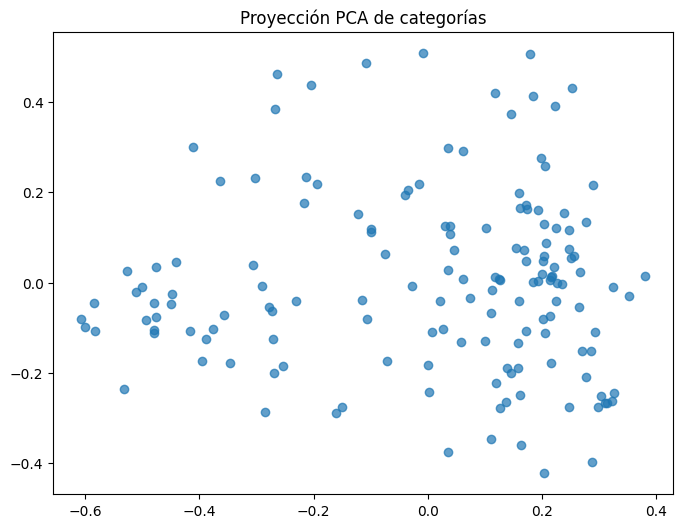

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(emb)

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1], alpha=0.7)
plt.title("Proyección PCA de categorías")
plt.show()